# Generate Segmentation

We have manual tracings done by hand on 2D dimensional slices, which we want to convert into the voxel space. We do that by placing a grid, which has the same dimension and spacing as the original image, and check if the points are in or outside. In cases where points are at the boundary, we estimate the partial volume by inplace a smaller grid onto the voxel. The code here is designed for the output of the Osirix Software, but can quite easily be used for different input shape. We have also the code used for bias correction bellow

In [12]:
import os, json
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from shapely.geometry import Point, LineString, MultiLineString, Polygon
from src.helper import reorient

In [7]:
# find the points where the tracing passes through
def get_intersection(points, grid):
    # start point
    out = [points[0]]
    intersecting = [False]
    
    # for each point we calculate the next intersection 
    for i in range(0, len(points)-1):
        p0 = points[i] # point we are looking at
        p1 = points[i + 1] # next point
        inter = grid.intersection(LineString([p0, p1])) # get the intersections

        # if it is a points
        if type(inter) == shapely.geometry.point.Point: # check if it is a point
            ps = [[inter.x, inter.y]]
        elif type(inter) == shapely.geometry.MultiPoint:
            ps = [[pt.x, pt.y] for pt in inter.geoms]
            i = np.argsort(np.sum((ps - p0)**2, axis=1)) # we want to keep the order
            ps = np.array(ps).take(i, 0).tolist()
        else:
            ps = []
            #print("Error: ", inter)

        # append
        out.extend(ps + [p1.tolist()]) # add intersecting points + next point to list
        intersecting.extend([True] * len(ps) + [False]) # keep track of which points are intersecting points

    return np.array(out), np.array(intersecting)

In [8]:
# generate a grid
def get_grid(shape):
    xmax, ymax, zmax = shape
    l = []
    
    for zi in np.arange(xmax):
        l.append([[zi, 0], [zi, zmax]])

    for xi in np.arange(zmax):
        l.append([[0, xi], [xmax, xi]])

    return MultiLineString(l)

In [9]:
# simply get if points are inside or outside in grid
def binarize2D(shape, poly):
    xmax, ymax, zmax = shape
    
    grid = []
    for yi in np.arange(ymax):
        line = []

        for zi in np.arange(zmax):
            inside = poly.contains(Point(yi + 0.5, zi + 0.5)) # we shift to right to be inside voxel
            line.append(inside)

        grid.append(line)

    return np.array(grid).astype(int)

In [11]:
# estimates volume inside of voxel 
def get_partial_estimate(poly, coor, step):
    x, z = coor
    v, c = 0, 0
    
    for zi in np.arange(z, z + 1, step):
        for xi in np.arange(x, x + 1, step):
            inside = poly.contains(Point(xi + step/2, zi + step/2))
            v += int(inside)
            c += 1
            
    return v/c

In [8]:
# create a 3D volume from the slices
def binarize3D(shape, tracings, region="wmgm", with_partial=True):
    seg = np.zeros(shape).astype(float)
    print("Binarizing", end="")

    for trace in tracings["Images"]:
        idx = trace["ImageIndex"]
        grid = get_grid(shape)

        for roi in trace["ROIs"]:
            if roi["Name"] == region:

                # read points
                points = np.array(json.loads(str(roi["Point_px"]).replace("'", "").replace("(", "[").replace(")", "]")))
                points, intersecting = get_intersection(points, grid)

                # create polygon
                y, x = points.T 
                poly = Polygon(list(zip(x, y)))
                binary_img = binarize2D(shape, poly).astype(float)
                
                if with_partial:
                    # get partial estimate
                    points = np.floor(points).astype(int)
                    for (x, y) in points:
                        binary_img[y, x] = get_partial_estimate(poly, (y, x), 0.1)

                # add slice to volume
                seg[idx, :, :] += binary_img
                
        print(".", end="", flush=True)

    # solves conflict when we have multiple slices
    seg = np.absolute(seg)
    seg[(seg % 2) == 0] = 0 # - - equals +
    seg[seg > 1] = 1

    return seg 

When loading the image, it is important that it has the same orientation as the tracings, otherwise they won't land in the same voxel space 

In [13]:
path = "../../DATA/Sealion/"
file = nib.load(path + "/rawdata_clean/_t2_space_Ax_iso_0.78mm_20190605082301_20.nii")

In [14]:
file = reorient(file, orientation="LIP")
img, affine = file.get_fdata(), file.affine
shape = img.shape
nib.aff2axcodes(affine), img.shape

Input: (0.78125, 0.78125, 0.78000003) [RAS]
Reorientating RAS to LIP


(('L', 'I', 'P'), (256, 320, 304))

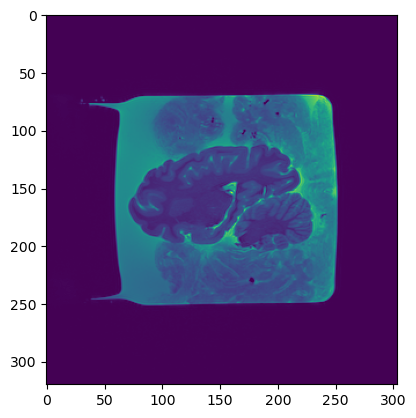

In [15]:
plt.imshow(img[100, :, :])

In [ ]:
with open(path + "/rawdata_clean/tracings.json") as file:
    tracings = json.loads(file.read())

In [15]:
trace = tracings["Images"][4]
idx = trace["ImageIndex"]
roi = trace["ROIs"][1]
points = np.array(json.loads(str(roi["Point_px"]).replace("'", "").replace("(", "[").replace(")", "]")))

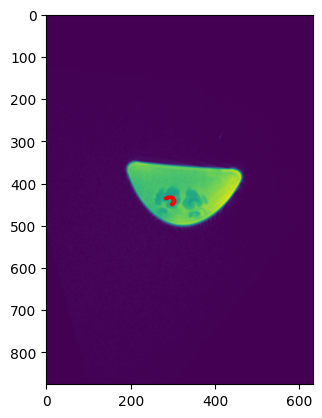

In [20]:
# check if the tracings are in correct orientation!!!
x, y = points.T
plt.plot(x, y, c="r", alpha=1)
plt.imshow(img[idx, :, :])

In [ ]:
volume = partialize3D(img.shape, tracings, region="WM")

In [ ]:
plt.imshow(volume[123])

In [ ]:
out_nib = nib.Nifti1Image(volume, affine)
nib.save(out_nib, os.path.join(path, "partial_segmentation", "wm.nii.gz"))

## Bias Correction

We observed better results by first applying bias correction. You have to set a treshold to consider where the algorithm will correct

In [13]:
import SimpleITK as sitk

In [50]:
# bias correction
def GetBiasCorrection(orig, threshold=10):
    # we use the defaults from
    # https://simpleitk.readthedocs.io/en/master/link_N4BiasFieldCorrection_docs.html
    inputImage = sitk.Cast(sitk.GetImageFromArray(orig), sitk.sitkFloat32)
    #maskImage = sitk.OtsuThreshold(inputImage, 0, 1, 200)
    maskImage = sitk.GetImageFromArray((orig > threshold).astype(np.uint8))
    corrector = sitk.N4BiasFieldCorrectionImageFilter()
    corrected_image = corrector.Execute(inputImage, maskImage)
    log_bias_field = corrector.GetLogBiasFieldAsImage(inputImage)
    bias_field = sitk.Cast(1 / sitk.Exp(log_bias_field), sitk.sitkFloat32)
    return sitk.GetArrayFromImage(inputImage * bias_field), sitk.GetArrayFromImage(bias_field)

(<matplotlib.image.AxesImage at 0x79a625d626b0>, (304, 320, 256))

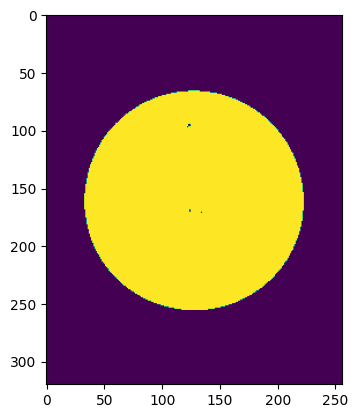

In [56]:
threshold = 100
plt.imshow(img[idx] > threshold), img.shape

In [57]:
new_img, bias = GetBiasCorrection(img,  threshold=threshold)

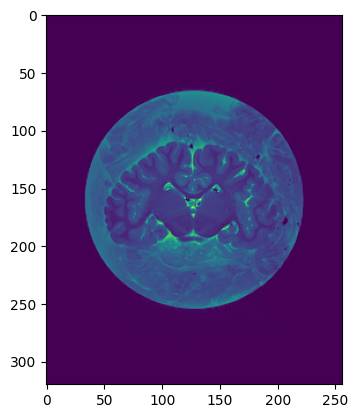

In [62]:
plt.imshow(new_img[idx])#, plt.imshow(bias[idx])

In [63]:
out_nib = nib.Nifti1Image(new_img, affine)
nib.save(out_nib, os.path.join(path, "img_unbiased.nii.gz"))